# Exp7.3.4 — Linear-pretrained LIF fine-tuning

Analysis-only notebook. It reads finalized artifacts and compares direct transfer, pretrained LIF fine-tuning, and random-init LIF training at the method level.

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()
while not (ROOT / 'pyproject.toml').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
ART = ROOT / 'notebooks' / 'artifacts' / 'experiment_7_3_4_linear_pretrained_lif_finetuning' / 'linear_pretrained_lif_finetuning_v1'
manifest = json.loads((ART / 'manifest.json').read_text())
method_runs = pd.read_csv(ART / 'method_runs.csv')
method_summary = pd.read_csv(ART / 'method_summary.csv')
contrast_summary = pd.read_csv(ART / 'contrast_summary.csv')
history_summary = pd.read_csv(ART / 'history_summary.csv')
checkpoint_diagnostics = pd.read_csv(ART / 'checkpoint_diagnostics.csv')
source_checks = pd.read_csv(ART / 'source_reproduction_checks.csv')
manifest

{'architecture': '234x234',
 'backbone_objective': 'wcce',
 'experiment_id': 'experiment_7_3_4_linear_pretrained_lif_finetuning',
 'frozen_backbone_contract': 'All runs reuse the exact Exp7.3 WCCE L2 cache sourced from A2; no L1/L2 parameter is instantiated as trainable.',
 'init_sources': ['a2', 'b6', 'random'],
 'lif_beta': 0.5,
 'logical_training_runs': 9,
 'max_abs_random_control_vs_exp73_b8_delta_pp': 0.5952380952380931,
 'notebook_contract': 'analysis-only; reads finalized CSV/JSON artifacts',
 'objective': 'wcce',
 'output_cap': 1,
 'primary_method_seed_rows': 15,
 'primary_metric': 'test_lif_ba from the best-validation-LIF-BA checkpoint',
 'protocol_version': 'linear_pretrained_lif_finetuning_v1',
 'random_control_contract': 'Random initialization reuses Exp7.3 Stage-2 model-init seed, loader order, optimizer, LIF dynamics, and WCCE objective and should reproduce B8.',
 'seeds': [11, 23, 37],
 'selection_rule': 'epoch 0 is a fixed direct-transfer reference and is excluded from 

## Primary method comparison

,method,checkpoint_role,test_lif_ba_mean,test_lif_ba_std,test_linear_ba_mean,test_linear_ba_std
0,A2_linearW_direct_lif,direct_transfer,0.524684,0.037378,0.564502,0.032830
1,A2_linearW_lif_finetune,best_val_ba,0.512317,0.042221,0.542885,0.042970
2,B6_linearW_direct_lif,direct_transfer,0.522762,0.012987,0.552707,0.036762
3,B6_linearW_lif_finetune,best_val_ba,0.504410,0.026636,0.541025,0.041949
4,randomW_lif_train,best_val_ba,0.510636,0.044104,0.500338,0.014477


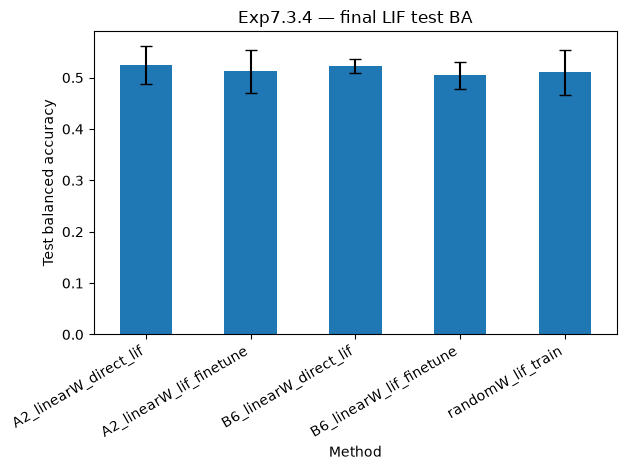

In [2]:
display(method_summary[['method', 'checkpoint_role', 'test_lif_ba_mean', 'test_lif_ba_std', 'test_linear_ba_mean', 'test_linear_ba_std']])
plot_df = method_summary.set_index('method')
ax = plot_df['test_lif_ba_mean'].plot(kind='bar', yerr=plot_df['test_lif_ba_std'], capsize=4)
ax.set_ylabel('Test balanced accuracy')
ax.set_xlabel('Method')
ax.set_title('Exp7.3.4 — final LIF test BA')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## Paired contrasts

In [3]:
display(contrast_summary.sort_values('contrast'))

,contrast,left_method,right_method,delta_pp_count,delta_pp_mean,delta_pp_std
0,A2_finetune_minus_direct,A2_linearW_lif_finetune,A2_linearW_direct_lif,3,-1.236703,0.633242
1,A2_finetune_minus_random,A2_linearW_lif_finetune,randomW_lif_train,3,0.168119,3.051767
2,B6_direct_minus_A2_direct,B6_linearW_direct_lif,A2_linearW_direct_lif,3,-0.192238,3.809654
3,B6_finetune_minus_A2_finetune,B6_linearW_lif_finetune,A2_linearW_lif_finetune,3,-0.790714,4.273138
4,B6_finetune_minus_direct,B6_linearW_lif_finetune,B6_linearW_direct_lif,3,-1.835179,1.463737
5,B6_finetune_minus_random,B6_linearW_lif_finetune,randomW_lif_train,3,-0.622595,2.549592


## Fine-tuning trajectory

Solid interpretation target: whether LIF BA improves while the same current W remains linearly discriminative, or whether LIF optimization trades away the Linear geometry.

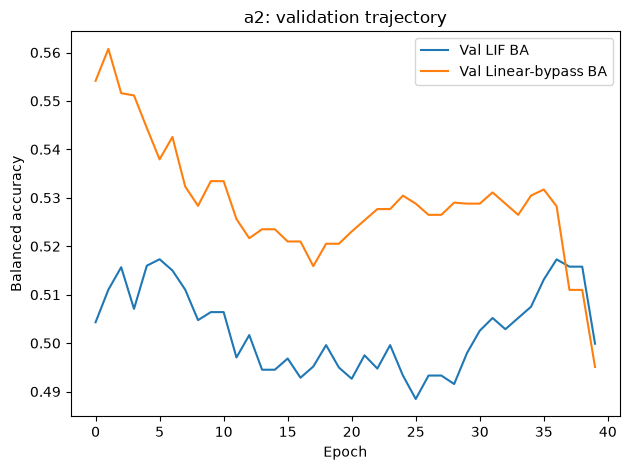

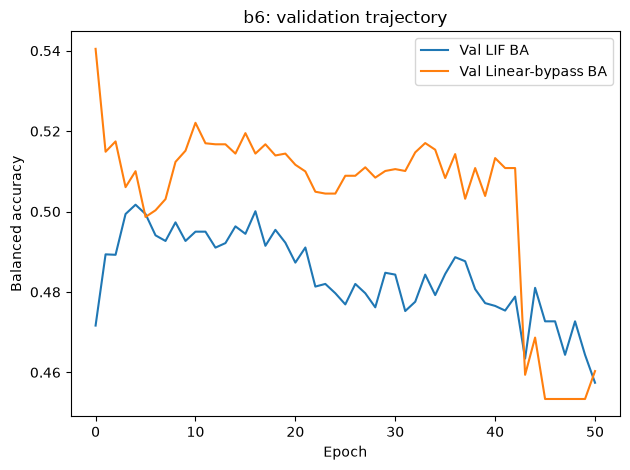

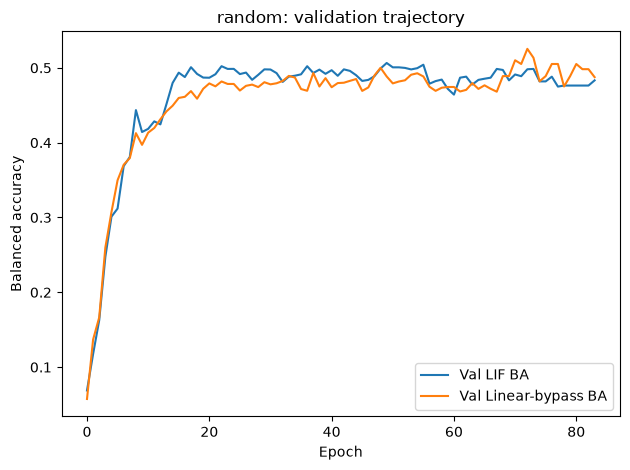

In [4]:
for init_source in ['a2', 'b6', 'random']:
    d = history_summary[history_summary.init_source == init_source].sort_values('epoch')
    fig, ax = plt.subplots()
    ax.plot(d['epoch'], d['val_lif_ba_mean'], label='Val LIF BA')
    ax.plot(d['epoch'], d['val_linear_ba_mean'], label='Val Linear-bypass BA')
    ax.set_title(f'{init_source}: validation trajectory')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Balanced accuracy')
    ax.legend()
    plt.tight_layout()
    plt.show()

## Weight drift

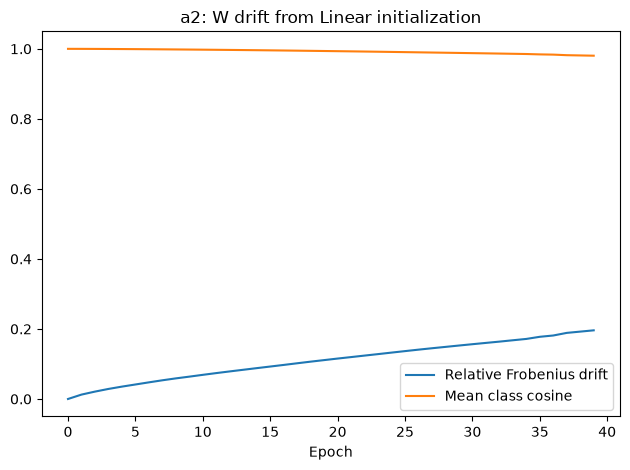

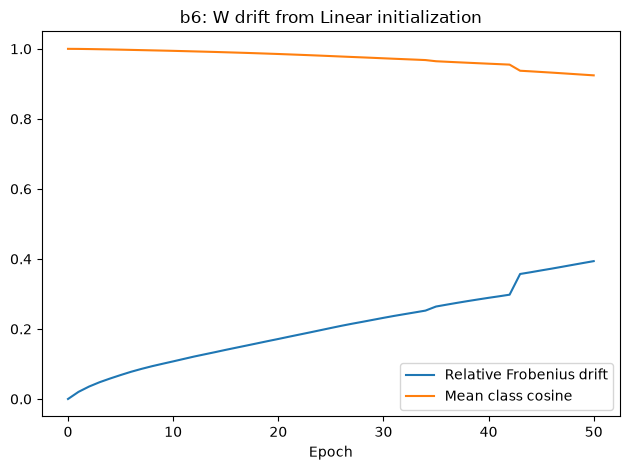

In [5]:
for init_source in ['a2', 'b6']:
    d = history_summary[history_summary.init_source == init_source].sort_values('epoch')
    fig, ax = plt.subplots()
    ax.plot(d['epoch'], d['weight_relative_frobenius_drift_mean'], label='Relative Frobenius drift')
    ax.plot(d['epoch'], d['weight_mean_class_cosine_mean'], label='Mean class cosine')
    ax.set_title(f'{init_source}: W drift from Linear initialization')
    ax.set_xlabel('Epoch')
    ax.legend()
    plt.tight_layout()
    plt.show()

## Output spike dynamics

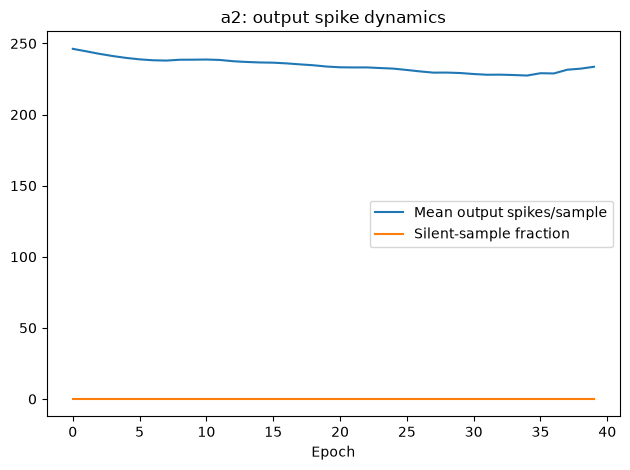

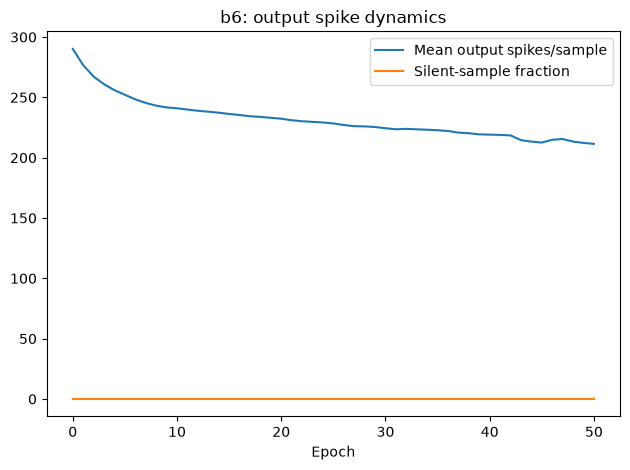

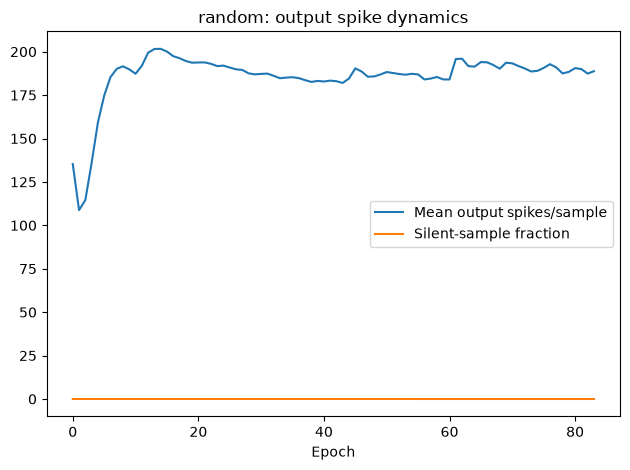

In [6]:
for init_source in ['a2', 'b6', 'random']:
    d = history_summary[history_summary.init_source == init_source].sort_values('epoch')
    fig, ax = plt.subplots()
    ax.plot(d['epoch'], d['val_mean_total_output_spikes_per_sample_mean'], label='Mean output spikes/sample')
    ax.plot(d['epoch'], d['val_silent_sample_fraction_mean'], label='Silent-sample fraction')
    ax.set_title(f'{init_source}: output spike dynamics')
    ax.set_xlabel('Epoch')
    ax.legend()
    plt.tight_layout()
    plt.show()

## Audit tables

In [7]:
display(checkpoint_diagnostics.sort_values(['init_source', 'seed', 'state']))
display(source_checks.sort_values(['init_source', 'seed']))

,seed,init_source,state,val_lif_ba,test_lif_ba,val_linear_ba,test_linear_ba,weight_relative_frobenius_drift,weight_norm_ratio,weight_mean_class_cosine
0,11,a2,best_val_ba,0.520749,0.503253,0.514364,0.497488,0.067401,1.005308,0.997744
1,11,a2,best_val_loss,0.499880,0.510062,0.495082,0.504631,0.196098,1.011247,0.980422
2,11,a2,epoch0,0.492971,0.512353,0.523653,0.530632,0.000000,1.000000,1.000000
3,11,a2,final,0.499880,0.510062,0.495082,0.504631,0.196098,1.011247,0.980422
4,23,a2,best_val_ba,0.529341,0.558335,0.544751,0.582925,0.047345,1.005576,0.998880
5,23,a2,best_val_loss,0.518789,0.553794,0.545509,0.596453,0.174079,1.014953,0.985003
6,23,a2,epoch0,0.525343,0.566670,0.572264,0.596182,0.000000,1.000000,1.000000
7,23,a2,final,0.518789,0.553794,0.545509,0.596453,0.177829,1.015252,0.984354
8,37,a2,best_val_ba,0.530604,0.475364,0.564893,0.548243,0.034689,1.004420,0.999429
9,37,a2,best_val_loss,0.482383,0.496791,0.534861,0.558396,0.159914,1.012102,0.987175


,seed,init_source,source_method,epoch0_lif_minus_exp73_lif_pp,epoch0_linear_minus_exp73_analog_pp,exp73_analog_test_ba,exp73_lif_test_ba,scratch_best_lif_minus_exp73_b8_pp,scratch_reproduces_exp73_b8,exp73_b8_native_test_ba,exp73_b8_final_lif_test_ba
0,11,a2,A2_e2e_linear_wcce,0.0,0.0,0.530632,0.512353,NaN,NaN,NaN,NaN
1,23,a2,A2_e2e_linear_wcce,0.0,0.0,0.596182,0.566670,NaN,NaN,NaN,NaN
2,37,a2,A2_e2e_linear_wcce,0.0,0.0,0.566691,0.495030,NaN,NaN,NaN,NaN
3,11,b6,B6_wcbackbone_linear_wcce,0.0,0.0,0.510258,0.507986,NaN,NaN,NaN,NaN
4,23,b6,B6_wcbackbone_linear_wcce,0.0,0.0,0.574186,0.527932,NaN,NaN,NaN,NaN
5,37,b6,B6_wcbackbone_linear_wcce,0.0,0.0,0.573676,0.532368,NaN,NaN,NaN,NaN
6,11,random,B8_wcbackbone_lif_wcce,NaN,NaN,NaN,NaN,0.595238,False,0.464526,0.464526
7,23,random,B8_wcbackbone_lif_wcce,NaN,NaN,NaN,NaN,0.000000,True,0.557839,0.557839
8,37,random,B8_wcbackbone_lif_wcce,NaN,NaN,NaN,NaN,0.000000,True,0.503591,0.503591
